# 05 — Machine-learning models (RF, XGBoost, LSTM; 1-day and 7-day horizons)

**Scope (Phase A, final report).** Random forest, XGBoost, and the LSTM at **both
forecast horizons**, per site, with hyperparameter search. Reproducibility: a fixed
project-wide seed (`SEED = 42`) is applied to Python, NumPy, scikit-learn/XGBoost,
and TensorFlow.

**Search modes.** The notebook runs in one of two modes, chosen by the
`NB05_SEARCH_MODE` environment variable (or by editing `SEARCH_MODE` in the first
code cell). **`full`** (the default) is the broadened search reported in the final
report: 27 random-forest and 72 XGBoost configurations, 12 LSTM configurations,
500-tree forests. It is intended for an unconstrained machine (local run or Google
Colab). **`quick`** is a reduced search (8 RF / 18 XGB / 4 LSTM configurations,
300-tree forests) for smoke checks and time-capped sandboxed execution.

**Checkpointing.** Every completed unit of model selection (one grid search, one
LSTM configuration, one final refit) is saved to `results/cache/nb05_<mode>/` as it
finishes, and re-running the notebook resumes from the cache instead of
recomputing. An optional wall-clock budget (`NB05_BUDGET_S` seconds) makes the run
stop cleanly once the budget is spent; rerunning continues where it left off. This
makes long searches robust to Colab disconnects and allows execution in
time-capped environments. Delete the cache directory to force a fresh search.

**Leakage control.** Direct forecasting strategy: to predict GHI on day *t+h*,
every feature is measured on or before the origin day *t* — today's GHI and its
lags 1–6, the 7-/30-day rolling means, today's five meteorological variables, and
the day-of-year harmonics of the origin day. Split (from `src/config.py`): train
2005–2020, validation 2021–2022; the 2023–2024 **test set stays untouched** until
notebook 06.

**Model-selection protocol.** Hyperparameters are selected on training-window data
only: the tree models via expanding-window time-series cross-validation
(`TimeSeriesSplit(3)`), the LSTM via a chronological tuning holdout inside the
training window (fit 2005–2018, tune 2019–2020) for computational tractability,
then a refit on the full training window with the selected configuration and epoch
count. The 2021–2022 validation window is used solely to compare the tuned models.
The selected configurations are saved to `results/ml_best_params.json`; notebook 06
refits them on 2005–2022 and evaluates **once** on 2023–2024.

In [1]:
import os, sys, json, time, random, pickle, warnings
sys.path.append('../src')
warnings.filterwarnings('ignore')
os.environ.setdefault('PYTHONHASHSEED', '42')
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import (SITES, PARAMETERS, DATA_PROCESSED, RESULTS, TRAIN_END, VAL_END)

SEED = 42                      # fixed project-wide seed (used in every notebook)
random.seed(SEED)
np.random.seed(SEED)

TARGET = 'ALLSKY_SFC_SW_DWN'
HORIZONS = [1, 7]
FIGDIR = RESULTS / 'figures'
FIGDIR.mkdir(parents=True, exist_ok=True)

# --- Search mode and optional execution budget ------------------------------
# SEARCH_MODE  'full'  = broad grids (default; local machine or Google Colab)
#              'quick' = reduced grids for smoke checks / sandboxed execution
# Override without editing the notebook:   NB05_SEARCH_MODE=quick
# NB05_BUDGET_S (optional): wall-clock seconds this run may spend on model
# selection; once spent, the run aborts cleanly and a rerun resumes from cache.
SEARCH_MODE = os.environ.get('NB05_SEARCH_MODE', 'full').lower()
assert SEARCH_MODE in ('full', 'quick'), f'bad SEARCH_MODE: {SEARCH_MODE}'
BUDGET_S = float(os.environ['NB05_BUDGET_S']) if os.environ.get('NB05_BUDGET_S') else None
RUN_T0 = time.time()

CACHE = RESULTS / 'cache' / f'nb05_{SEARCH_MODE}'
CACHE.mkdir(parents=True, exist_ok=True)

class BudgetExhausted(RuntimeError):
    """Raised when NB05_BUDGET_S is used up; rerun the notebook to resume."""

def budget_left():
    return None if BUDGET_S is None else BUDGET_S - (time.time() - RUN_T0)

def require_budget(seconds_needed):
    """Abort cleanly unless `seconds_needed` seconds of budget remain."""
    left = budget_left()
    if left is not None and left < seconds_needed:
        raise BudgetExhausted(
            f'{left:.0f}s of budget left (<{seconds_needed}s needed); '
            'rerun the notebook to resume from results/cache/.')

# Cached objects are stored as plain dicts (not pickled pandas objects) so the
# cache stays readable across pandas/numpy versions (local, Colab, sandbox).
def _pack_series(s):
    return {'dates': s.index.strftime('%Y-%m-%d').tolist(),
            'values': [float(v) for v in s.to_numpy()]}

def _unpack_series(d):
    return pd.Series(d['values'], index=pd.to_datetime(d['dates']))

SITE_ORDER = ['navrongo', 'tamale', 'kumasi', 'accra', 'takoradi']
SITE_COLOR = {'navrongo': '#D55E00', 'tamale': '#0072B2', 'kumasi': '#009E73',
              'accra': '#E69F00', 'takoradi': '#CC79A7'}
SITE_LABEL = {k: SITES[k]['name'] for k in SITES}

plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 200, 'savefig.bbox': 'tight',
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'axes.axisbelow': True})

print(f'Search mode: {SEARCH_MODE}'
      + (f' | budget: {BUDGET_S:.0f}s' if BUDGET_S else ' | budget: none'))

Search mode: full | budget: none


## 5.1 Feature matrix (all features known at the origin day *t*)

In [2]:
df = pd.read_csv(DATA_PROCESSED / 'all_sites_daily.csv', parse_dates=['date'])
df = df.set_index('date')
train_end = pd.Timestamp(TRAIN_END)
val_end = pd.Timestamp(VAL_END)

MET = ['T2M', 'RH2M', 'CLOUD_AMT', 'PRECTOTCORR', 'WS2M']
FEATURES = ([TARGET]                                  # today's GHI (lag 0 w.r.t. origin)
            + [f'ghi_lag{l}' for l in range(1, 7)]    # y_{t-1} … y_{t-6}
            + ['ghi_roll7', 'ghi_roll30']             # rolling means up to t
            + MET                                     # today's weather
            + ['doy_sin', 'doy_cos'])                 # calendar position

def make_xy(site_df, horizon=1):
    X = site_df[FEATURES].copy()
    y = site_df[TARGET].shift(-horizon)               # target = GHI at t + h
    ok = X.notna().all(axis=1) & y.notna()
    return X[ok], y[ok]

def metrics(y, yhat):
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    rmse = float(np.sqrt(np.mean((y - yhat) ** 2)))
    mae = float(np.mean(np.abs(y - yhat)))
    r2 = float(1 - np.sum((y - yhat) ** 2) / np.sum((y - y.mean()) ** 2))
    return rmse, mae, r2

print(f'{len(FEATURES)} features:', FEATURES)


16 features: ['ALLSKY_SFC_SW_DWN', 'ghi_lag1', 'ghi_lag2', 'ghi_lag3', 'ghi_lag4', 'ghi_lag5', 'ghi_lag6', 'ghi_roll7', 'ghi_roll30', 'T2M', 'RH2M', 'CLOUD_AMT', 'PRECTOTCORR', 'WS2M', 'doy_sin', 'doy_cos']


## 5.2 Tree ensembles: grids under time-series cross-validation

Grid search per site, model, and horizon over 3 expanding-window folds
(`TimeSeriesSplit(3)`) on the training window only, parallelized across
configurations (`n_jobs=-1`) with single-threaded estimators, which uses all
cores without oversubscription.

| Mode | Random forest | XGBoost |
|---|---|---|
| `full` | 27 configs (max_depth × min_samples_leaf × max_features), 500 trees | 72 configs (max_depth × learning_rate × subsample × colsample_bytree × min_child_weight) |
| `quick` | 8 configs, 300 trees | 18 configs (max_depth × learning_rate × subsample) |

Each completed search (one site × model × horizon) is checkpointed to the cache,
so an interrupted run resumes with no recomputation.

In [3]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor

CV = TimeSeriesSplit(n_splits=3)

RF_TREES = {'full': 500, 'quick': 300}[SEARCH_MODE]
TREE_GRIDS = {
    'full': {
        'Random forest':                                            # 27 configs
            {'max_depth': [10, 20, None],
             'min_samples_leaf': [1, 2, 5],
             'max_features': ['sqrt', 0.5, 1.0]},
        'XGBoost':                                                  # 72 configs
            {'max_depth': [3, 5, 7],
             'learning_rate': [0.03, 0.05, 0.10],
             'subsample': [0.8, 1.0],
             'colsample_bytree': [0.8, 1.0],
             'min_child_weight': [1, 5]},
    },
    'quick': {
        'Random forest':                                            # 8 configs
            {'max_depth': [20, None],
             'min_samples_leaf': [2, 5],
             'max_features': ['sqrt', 0.5]},
        'XGBoost':                                                  # 18 configs
            {'max_depth': [3, 5, 7],
             'learning_rate': [0.03, 0.05, 0.10],
             'subsample': [0.8, 1.0],
             'colsample_bytree': [0.8],
             'min_child_weight': [5]},
    },
}
# rough cost of one uncached grid search on a constrained machine (budget gating)
UNIT_COST_S = {'Random forest': 100, 'XGBoost': 30}

def make_estimator(name):
    if name == 'Random forest':
        return RandomForestRegressor(n_estimators=RF_TREES, random_state=SEED, n_jobs=1)
    return XGBRegressor(n_estimators=800, objective='reg:squarederror',
                        random_state=SEED, n_jobs=1, verbosity=0)

rows, best_params, importances, preds_store, train_times = [], {}, {}, {}, []

for h in HORIZONS:
    for key in SITE_ORDER:
        sdf = df[df['site'] == key]
        X, y = make_xy(sdf, horizon=h)
        X_tr, y_tr = X[X.index <= train_end], y[X.index <= train_end]
        val_mask = (X.index > train_end) & (X.index <= val_end)
        X_va, y_va = X[val_mask], y[val_mask]

        for model_name in ('Random forest', 'XGBoost'):
            cpath = CACHE / f"tree_{key}_{model_name.replace(' ', '')}_{h}d.pkl"
            if cpath.exists():
                with open(cpath, 'rb') as fh:
                    unit = pickle.load(fh)
            else:
                require_budget(UNIT_COST_S[model_name])
                gs = GridSearchCV(make_estimator(model_name),
                                  TREE_GRIDS[SEARCH_MODE][model_name], cv=CV,
                                  scoring='neg_root_mean_squared_error', n_jobs=-1)
                t0 = time.time()
                gs.fit(X_tr, y_tr)                 # CV search + refit on 2005-2020
                train_s = round(time.time() - t0, 1)
                yhat = gs.best_estimator_.predict(X_va)
                rmse, mae, r2 = metrics(y_va, yhat)
                unit = {'row': {'Site': SITE_LABEL[key], 'Model': model_name,
                                'Horizon': f'{h}-day', 'RMSE': rmse, 'MAE': mae,
                                'R2': r2, 'N': len(y_va)},
                        'best': gs.best_params_,
                        'pred': _pack_series(pd.Series(yhat, index=y_va.index)),
                        'imp': (dict(zip(FEATURES,
                                         map(float, gs.best_estimator_.feature_importances_)))
                                if model_name == 'XGBoost' and h == 1 else None),
                        'train_s': train_s,
                        'train_s_src': 'measured'}
                with open(cpath, 'wb') as fh:
                    pickle.dump(unit, fh)
            rows.append(unit['row'])
            best_params[(key, model_name, h)] = unit['best']
            preds_store[(key, model_name, h)] = _unpack_series(unit['pred'])
            if unit['imp'] is not None:
                importances[key] = pd.Series(unit['imp'])
            train_times.append({'Site': SITE_LABEL[key], 'Model': model_name,
                                'Horizon': f'{h}-day',
                                'Selection_s': unit.get('train_s', np.nan),
                                'Refit_s': np.nan,   # refit included in Selection_s
                                'Total_s': unit.get('train_s', np.nan),
                                'Source': unit.get('train_s_src', 'not recorded')})
        print(f'{SITE_LABEL[key]:<9} {h}-day done  '
              f'RF={best_params[(key, "Random forest", h)]}  '
              f'XGB={best_params[(key, "XGBoost", h)]}')

Navrongo  1-day done  RF={'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5}  XGB={'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 5, 'subsample': 0.8}
Tamale    1-day done  RF={'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 5}  XGB={'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 5, 'subsample': 1.0}
Kumasi    1-day done  RF={'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5}  XGB={'colsample_bytree': 1.0, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 1, 'subsample': 0.8}
Accra     1-day done  RF={'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2}  XGB={'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 5, 'subsample': 1.0}
Takoradi  1-day done  RF={'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 5}  XGB={'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 5, 'subsample

## 5.3 LSTM (30-day input windows)

Each sample is a 30-day window of the same features (standardized with a scaler
fit on training-window rows only), ending at the origin day *t*; the target is GHI
at *t+h*, so the leakage discipline matches the tree models exactly.

Search grids: **`full`** — 12 configurations (units 32/64/128 × 1–2 layers ×
dropout 0/0.2); **`quick`** — 4 configurations (units 64/128 × 1–2 layers,
dropout 0.2). Each configuration is trained epoch by epoch with manual early
stopping equivalent to `EarlyStopping(patience=8, restore_best_weights=True)`
against the chronological tuning holdout (2019–2020), up to 80 epochs. The
winning configuration is refit on the full training window for its selected epoch
count, then scored once on the 2021–2022 validation window.

Training is **checkpointed**: each configuration saves its weights, epoch counter,
and early-stopping state to the cache after every budgeted run, so an interrupted
search resumes mid-training. `keras.utils.set_random_seed(SEED)` is applied at the
start of every configuration (an uninterrupted run — the reported `full` runs —
is fully seeded end to end; a budget-resumed run reseeds deterministically at the
resume epoch).

In [4]:
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler
from numpy.lib.stride_tricks import sliding_window_view

tf.get_logger().setLevel('ERROR')

WINDOW = 30
TUNE_END = pd.Timestamp('2018-12-31')      # fit 2005-2018, tune 2019-2020
MAX_EPOCHS, PATIENCE, BATCH = 80, 8, 64
LSTM_GRIDS = {
    'full':  [dict(units=u, n_layers=l, dropout=d)                 # 12 configs
              for u in (32, 64, 128) for l in (1, 2) for d in (0.0, 0.2)],
    'quick': [dict(units=u, n_layers=l, dropout=0.2)               # 4 configs
              for u in (64, 128) for l in (1, 2)],
}
LSTM_GRID = LSTM_GRIDS[SEARCH_MODE]

def build_lstm(n_features, units, n_layers, dropout):
    model = keras.Sequential()
    model.add(keras.Input(shape=(WINDOW, n_features)))
    for i in range(n_layers):
        model.add(keras.layers.LSTM(units, return_sequences=(i < n_layers - 1)))
        if dropout > 0:
            model.add(keras.layers.Dropout(dropout))
    model.add(keras.layers.Dense(1))
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
    return model

def train_checkpointed(tag, n_features, cfg, X_fit, y_fit, X_val=None, y_val=None,
                       max_epochs=MAX_EPOCHS, patience=PATIENCE):
    """Epoch-by-epoch training with on-disk checkpoints (resumable across runs).

    Early stopping mirrors `EarlyStopping(patience, restore_best_weights=True)`:
    training stops once `patience` epochs pass without a val_loss improvement;
    best.keras holds the best-epoch weights. Cumulative training wall time is
    recorded in the state (`train_s`). Raises BudgetExhausted (after saving a
    checkpoint) when the wall-clock budget runs out. Returns the state dict."""
    sdir = CACHE / f'lstm_{tag}'
    sdir.mkdir(exist_ok=True)
    sfile, mfile = sdir / 'state.json', sdir / 'model.keras'
    if sfile.exists():
        with open(sfile) as fh:
            state = json.load(fh)
        if state['done']:
            return state
        model = keras.models.load_model(mfile)
        keras.utils.set_random_seed(SEED + state['epoch'])   # deterministic resume
    else:
        keras.utils.set_random_seed(SEED)
        model = build_lstm(n_features, **cfg)
        state = {'cfg': cfg, 'epoch': 0, 'best_val': None, 'best_epoch': 0,
                 'train_s': 0.0, 'done': False}
    val = (X_val, y_val) if X_val is not None else None
    while state['epoch'] < max_epochs:
        try:
            require_budget(20)                    # headroom to checkpoint safely
        except BudgetExhausted:
            model.save(mfile)
            with open(sfile, 'w') as fh:
                json.dump(state, fh)
            raise
        t0 = time.time()
        hist = model.fit(X_fit, y_fit, validation_data=val, epochs=1,
                         batch_size=BATCH, verbose=0)
        state['train_s'] = round(state.get('train_s', 0.0) + time.time() - t0, 1)
        state['epoch'] += 1
        if val is not None:
            vl = float(hist.history['val_loss'][0])
            if state['best_val'] is None or vl < state['best_val']:
                state['best_val'], state['best_epoch'] = vl, state['epoch']
                model.save(sdir / 'best.keras')
            elif state['epoch'] - state['best_epoch'] >= patience:
                break
    state['done'] = True
    model.save(mfile)
    with open(sfile, 'w') as fh:
        json.dump(state, fh)
    return state

lstm_log = []
for h in HORIZONS:
    for key in SITE_ORDER:
        fpath = CACHE / f'lstm_final_{key}_{h}d.pkl'
        if not fpath.exists():
            sdf = df[df['site'] == key].sort_index()
            X_all = sdf[FEATURES]
            y_all = sdf[TARGET].shift(-h)
            ok = X_all.notna().all(axis=1)            # drops the warm-up prefix only
            X_all, y_all = X_all[ok], y_all[ok]
            dates = X_all.index

            scaler = StandardScaler().fit(X_all[dates <= train_end])
            Xs = scaler.transform(X_all).astype('float32')
            W = sliding_window_view(Xs, (WINDOW, Xs.shape[1])).squeeze(axis=1)
            end_dates = dates[WINDOW - 1:]
            yW = y_all.iloc[WINDOW - 1:].to_numpy(dtype='float32')
            keep = ~np.isnan(yW)
            W, end_dates, yW = W[keep], end_dates[keep], yW[keep]

            fit_m = end_dates <= TUNE_END
            tune_m = (end_dates > TUNE_END) & (end_dates <= train_end)
            val_m = (end_dates > train_end) & (end_dates <= val_end)
            train_m = end_dates <= train_end
            nf = W.shape[2]

            best, log = None, []
            for ci, cfg in enumerate(LSTM_GRID):
                st = train_checkpointed(f'{key}_{h}d_cfg{ci}', nf, cfg,
                                        W[fit_m], yW[fit_m], W[tune_m], yW[tune_m])
                tune_rmse = float(np.sqrt(st['best_val']))
                log.append({'site': key, 'horizon': f'{h}-day', **cfg,
                            'tune_rmse': round(tune_rmse, 4),
                            'best_epoch': st['best_epoch'],
                            'train_s': st.get('train_s', np.nan)})
                if best is None or tune_rmse < best['tune_rmse']:
                    best = {**cfg, 'tune_rmse': tune_rmse,
                            'best_epoch': st['best_epoch']}

            # final refit on the full training window at the selected epoch count
            fst = train_checkpointed(f'{key}_{h}d_final', nf,
                                     {k: best[k] for k in ('units', 'n_layers', 'dropout')},
                                     W[train_m], yW[train_m],
                                     max_epochs=best['best_epoch'])
            final = keras.models.load_model(CACHE / f'lstm_{key}_{h}d_final'
                                            / 'model.keras')
            yhat = final.predict(W[val_m], verbose=0).ravel()
            rmse, mae, r2 = metrics(yW[val_m], yhat)
            sel_s = round(sum(e.get('train_s') or 0 for e in log), 1)
            refit_s = fst.get('train_s', np.nan)
            unit = {'row': {'Site': SITE_LABEL[key], 'Model': 'LSTM',
                            'Horizon': f'{h}-day', 'RMSE': rmse, 'MAE': mae,
                            'R2': r2, 'N': int(val_m.sum())},
                    'best': {**{k: best[k] for k in ('units', 'n_layers', 'dropout')},
                             'best_epoch': best['best_epoch']},
                    'pred': _pack_series(pd.Series(yhat, index=end_dates[val_m])),
                    'log': log,
                    'sel_s': sel_s, 'refit_s': refit_s,
                    'train_s': round(sel_s + (refit_s or 0), 1),
                    'train_s_src': 'measured'}
            with open(fpath, 'wb') as fh:
                pickle.dump(unit, fh)
        with open(fpath, 'rb') as fh:
            unit = pickle.load(fh)
        rows.append(unit['row'])
        best_params[(key, 'LSTM', h)] = unit['best']
        preds_store[(key, 'LSTM', h)] = _unpack_series(unit['pred'])
        lstm_log += unit['log']
        train_times.append({'Site': SITE_LABEL[key], 'Model': 'LSTM',
                            'Horizon': f'{h}-day',
                            'Selection_s': unit.get('sel_s', np.nan),
                            'Refit_s': unit.get('refit_s', np.nan),
                            'Total_s': unit.get('train_s', np.nan),
                            'Source': unit.get('train_s_src', 'not recorded')})
        print(f"{SITE_LABEL[key]:<9} {h}-day LSTM done  cfg={unit['best']}  "
              f"val RMSE={unit['row']['RMSE']:.3f}")

pd.DataFrame(lstm_log).to_csv(RESULTS / 'lstm_tuning_log.csv', index=False)

Navrongo  1-day LSTM done  cfg={'units': 64, 'n_layers': 2, 'dropout': 0.2, 'best_epoch': 15}  val RMSE=0.914
Tamale    1-day LSTM done  cfg={'units': 128, 'n_layers': 2, 'dropout': 0.2, 'best_epoch': 15}  val RMSE=0.867
Kumasi    1-day LSTM done  cfg={'units': 32, 'n_layers': 2, 'dropout': 0.2, 'best_epoch': 36}  val RMSE=0.686
Accra     1-day LSTM done  cfg={'units': 128, 'n_layers': 2, 'dropout': 0.2, 'best_epoch': 7}  val RMSE=0.826
Takoradi  1-day LSTM done  cfg={'units': 64, 'n_layers': 2, 'dropout': 0.2, 'best_epoch': 7}  val RMSE=0.953
Navrongo  7-day LSTM done  cfg={'units': 32, 'n_layers': 1, 'dropout': 0.2, 'best_epoch': 16}  val RMSE=0.967
Tamale    7-day LSTM done  cfg={'units': 128, 'n_layers': 1, 'dropout': 0.2, 'best_epoch': 12}  val RMSE=0.908
Kumasi    7-day LSTM done  cfg={'units': 32, 'n_layers': 2, 'dropout': 0.0, 'best_epoch': 21}  val RMSE=0.723
Accra     7-day LSTM done  cfg={'units': 32, 'n_layers': 2, 'dropout': 0.2, 'best_epoch': 6}  val RMSE=0.870
Takoradi  

## 5.4 Validation results (2021–2022): all three ML models vs. DHR, both horizons

Saved outputs: `ml_1day_metrics.csv`, `ml_7day_metrics.csv`, `ml_vs_dhr_1day.csv`,
`ml_vs_dhr_7day.csv`, `ml_best_params.json` (consumed by notebook 06),
`val_predictions_ml.csv`, `lstm_tuning_log.csv`, `ml_training_times.csv`.


In [5]:
ml = pd.DataFrame(rows).round(3)
for h in HORIZONS:
    ml[ml['Horizon'] == f'{h}-day'].to_csv(RESULTS / f'ml_{h}day_metrics.csv', index=False)

base = pd.read_csv(RESULTS / 'baseline_metrics.csv')
dhr = base[base['Model'] == 'DHR'][['Site', 'Horizon', 'RMSE']] \
        .rename(columns={'RMSE': 'DHR RMSE'})
comp = ml.merge(dhr, on=['Site', 'Horizon'])
comp['Skill vs DHR (%)'] = (100 * (comp['DHR RMSE'] - comp['RMSE'])
                            / comp['DHR RMSE']).round(1)
comp = comp[['Site', 'Model', 'Horizon', 'RMSE', 'MAE', 'R2',
             'DHR RMSE', 'Skill vs DHR (%)']]
for h in HORIZONS:
    comp[comp['Horizon'] == f'{h}-day'].drop(columns='Horizon') \
        .to_csv(RESULTS / f'ml_vs_dhr_{h}day.csv', index=False)

best_out = {f'{site}|{model}|{h}-day': params
            for (site, model, h), params in best_params.items()}
best_out['_meta'] = {'search_mode': SEARCH_MODE, 'seed': SEED,
                     'rf_n_estimators': RF_TREES}
with open(RESULTS / 'ml_best_params.json', 'w') as f:
    json.dump(best_out, f, indent=2, default=str)

pred_rows = [pd.DataFrame({'date': s.index, 'site': site, 'model': model,
                           'horizon': f'{h}-day', 'yhat': s.values})
             for (site, model, h), s in preds_store.items()]
pd.concat(pred_rows).to_csv(RESULTS / 'val_predictions_ml.csv', index=False)

comp


,Site,Model,Horizon,RMSE,MAE,R2,DHR RMSE,Skill vs DHR (%)
0,Navrongo,Random forest,1-day,0.924,0.664,0.215,0.939,1.6
1,Navrongo,XGBoost,1-day,0.938,0.671,0.191,0.939,0.1
2,Tamale,Random forest,1-day,0.859,0.624,0.258,0.882,2.6
3,Tamale,XGBoost,1-day,0.881,0.635,0.220,0.882,0.1
4,Kumasi,Random forest,1-day,0.682,0.500,0.295,0.699,2.4
5,Kumasi,XGBoost,1-day,0.693,0.510,0.272,0.699,0.9
6,Accra,Random forest,1-day,0.819,0.599,0.181,0.863,5.1
7,Accra,XGBoost,1-day,0.829,0.602,0.162,0.863,3.9
8,Takoradi,Random forest,1-day,0.946,0.722,0.177,0.992,4.6
9,Takoradi,XGBoost,1-day,0.943,0.716,0.182,0.992,4.9


### Figure 5-1 — validation RMSE: classical vs. ML (1-day)

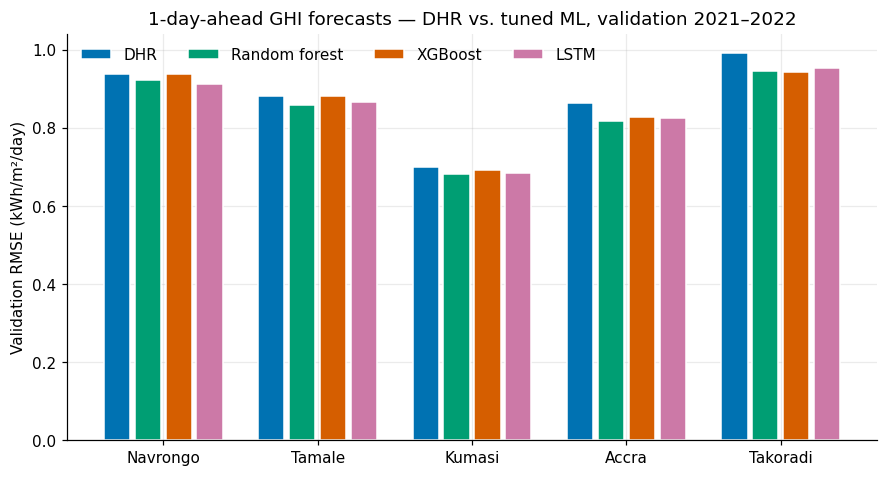

In [6]:
MODEL_COLOR = {'DHR': '#0072B2', 'Random forest': '#009E73',
               'XGBoost': '#D55E00', 'LSTM': '#CC79A7'}

def rmse_bars(horizon, fname, title):
    fig, ax = plt.subplots(figsize=(9.5, 4.8))
    xs = np.arange(len(SITE_ORDER))
    plot_models = ['DHR', 'Random forest', 'XGBoost', 'LSTM']
    width = 0.2
    for i, model in enumerate(plot_models):
        if model == 'DHR':
            vals = [dhr[(dhr['Site'] == SITE_LABEL[k])
                        & (dhr['Horizon'] == horizon)]['DHR RMSE'].iloc[0]
                    for k in SITE_ORDER]
        else:
            vals = [ml[(ml['Site'] == SITE_LABEL[k]) & (ml['Model'] == model)
                       & (ml['Horizon'] == horizon)]['RMSE'].iloc[0]
                    for k in SITE_ORDER]
        ax.bar(xs + (i - 1.5) * width, vals, width - 0.03, color=MODEL_COLOR[model],
               label=model, edgecolor='white', linewidth=1)
    ax.set_xticks(xs); ax.set_xticklabels([SITE_LABEL[k] for k in SITE_ORDER])
    ax.set_ylabel('Validation RMSE (kWh/m²/day)')
    ax.set_title(title)
    ax.legend(frameon=False, ncols=4)
    fig.savefig(FIGDIR / fname)
    plt.show()

rmse_bars('1-day', 'fig_05_1_ml_vs_dhr.png',
          '1-day-ahead GHI forecasts — DHR vs. tuned ML, validation 2021–2022')


### Figure 5-2 — XGBoost feature importance (preliminary RQ2 signal)

Gain importance from the tuned 1-day XGBoost per site, averaged. Formal, model-
agnostic SHAP analysis on the untouched test set follows in notebook 06.


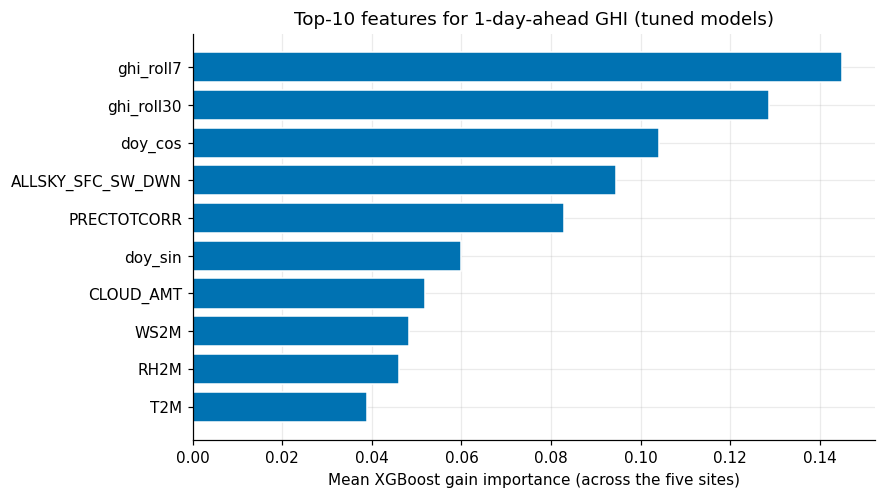

,Navrongo,Tamale,Kumasi,Accra,Takoradi
ALLSKY_SFC_SW_DWN,0.105,0.086,0.070,0.061,0.150
ghi_lag1,0.048,0.032,0.028,0.027,0.040
ghi_lag2,0.038,0.031,0.033,0.046,0.041
ghi_lag3,0.045,0.030,0.024,0.029,0.046
ghi_lag4,0.038,0.027,0.028,0.026,0.037
ghi_lag5,0.037,0.025,0.024,0.026,0.039
ghi_lag6,0.038,0.029,0.024,0.032,0.035
ghi_roll7,0.066,0.222,0.282,0.098,0.057
ghi_roll30,0.088,0.185,0.198,0.120,0.052
T2M,0.048,0.026,0.026,0.046,0.049


In [7]:
imp = pd.DataFrame(importances)[SITE_ORDER]
imp.columns = [SITE_LABEL[k] for k in SITE_ORDER]
imp_mean = imp.mean(axis=1).sort_values(ascending=True)
top = imp_mean.tail(10)

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.barh(range(len(top)), top.values, color='#0072B2', edgecolor='white')
ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index)
ax.set_xlabel('Mean XGBoost gain importance (across the five sites)')
ax.set_title('Top-10 features for 1-day-ahead GHI (tuned models)')
fig.savefig(FIGDIR / 'fig_05_2_feature_importance.png')
plt.show()

imp.round(3).to_csv(RESULTS / 'ml_feature_importance_1day.csv')
imp.round(3)


### Figure 5-3 — validation RMSE: classical vs. ML (7-day)

At 7 days DHR collapses toward climatology (notebook 04), so this figure shows how
much anomaly signal the ML models can still extract a week ahead.


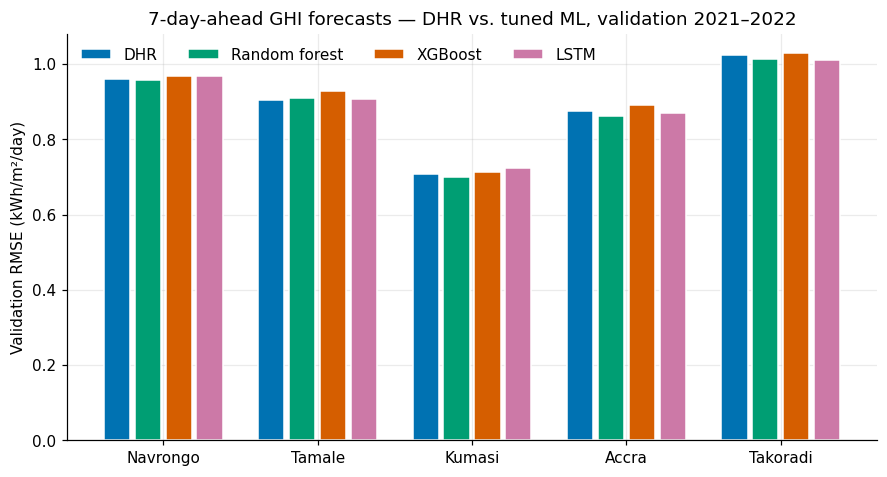

In [8]:
rmse_bars('7-day', 'fig_05_3_ml_vs_dhr_7day.png',
          '7-day-ahead GHI forecasts — DHR vs. tuned ML, validation 2021–2022')


In [9]:
for h in HORIZONS:
    sub = comp[comp['Horizon'] == f'{h}-day']
    print(f'--- {h}-day validation (2021-2022) ---')
    for model in ['Random forest', 'XGBoost', 'LSTM']:
        s = sub[sub['Model'] == model]['Skill vs DHR (%)']
        print(f'  {model:<14} skill vs DHR: min {s.min():+.1f}%  '
              f'median {s.median():+.1f}%  max {s.max():+.1f}%')
    best_by_site = sub.loc[sub.groupby('Site')['RMSE'].idxmin(),
                           ['Site', 'Model', 'RMSE', 'Skill vs DHR (%)']]
    print(best_by_site.to_string(index=False), '\n')


--- 1-day validation (2021-2022) ---
  Random forest  skill vs DHR: min +1.6%  median +2.6%  max +5.1%
  XGBoost        skill vs DHR: min +0.1%  median +0.9%  max +4.9%
  LSTM           skill vs DHR: min +1.7%  median +2.7%  max +4.3%
    Site         Model  RMSE  Skill vs DHR (%)
   Accra Random forest 0.819               5.1
  Kumasi Random forest 0.682               2.4
Navrongo          LSTM 0.914               2.7
Takoradi       XGBoost 0.943               4.9
  Tamale Random forest 0.859               2.6 

--- 7-day validation (2021-2022) ---
  Random forest  skill vs DHR: min -0.6%  median +1.0%  max +1.4%
  XGBoost        skill vs DHR: min -2.7%  median -1.0%  max -0.4%
  LSTM           skill vs DHR: min -2.0%  median -0.3%  max +1.2%
    Site         Model  RMSE  Skill vs DHR (%)
   Accra Random forest 0.862               1.4
  Kumasi Random forest 0.699               1.4
Navrongo Random forest 0.958               0.1
Takoradi          LSTM 1.011               1.2
  Tamale   

## 5.5 Training cost

Wall-clock training time per site, model, and horizon, captured during model
selection. For the tree models, one entry covers the whole `GridSearchCV` (all
configurations × 3 expanding-window folds, plus the final refit on 2005–2020).
For the LSTM, selection is the summed epoch-by-epoch training time across all
configurations, and the refit is timed separately; per-configuration times are
also recorded in `lstm_tuning_log.csv`.

Timings are stored inside the cache units, so cached reruns report the original
training cost. The `Source` column distinguishes in-process measurements
(`measured`) from entries reconstructed after the fact from cache artifact
timestamps of an uninterrupted sequential run (`artifact timestamps`, accurate
to within a few seconds). Saved to `ml_training_times.csv`; Figure 5-4 compares
the totals.

                       mean s per site  total s
Model         Horizon                          
LSTM          1-day              547.2   2736.0
              7-day              383.1   1915.6
Random forest 1-day               79.5    397.7
              7-day               71.5    357.3
XGBoost       1-day               35.1    175.4
              7-day               36.2    180.8 

Grand total: 96.0 min (artifact timestamps)


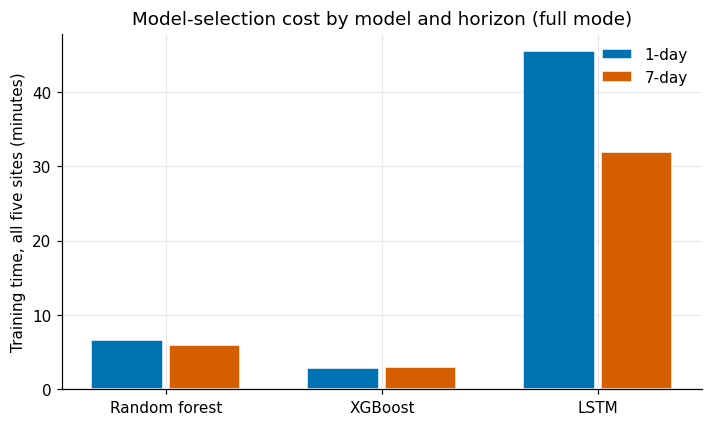

Model      LSTM        Random forest       XGBoost      
Horizon   1-day  7-day         1-day 7-day   1-day 7-day
Site                                                    
Accra     378.4  268.7          86.0  74.0    39.1  31.3
Kumasi    738.8  497.9          62.1  81.5    33.5  47.9
Navrongo  553.2  414.4          80.0  62.9    41.4  30.8
Takoradi  401.0  246.6          95.6  66.4    31.0  29.2
Tamale    664.6  488.0          74.0  72.5    30.4  41.6

In [10]:
tt = pd.DataFrame(train_times)
tt.to_csv(RESULTS / 'ml_training_times.csv', index=False)

per_model = tt.groupby(['Model', 'Horizon'])['Total_s'].agg(['mean', 'sum']).round(1)
per_model.columns = ['mean s per site', 'total s']
print(per_model, '\n')
print(f"Grand total: {tt['Total_s'].sum() / 60:.1f} min "
      f"({', '.join(sorted(tt['Source'].unique()))})")

fig, ax = plt.subplots(figsize=(7.5, 4.2))
plot_models = ['Random forest', 'XGBoost', 'LSTM']
xs = np.arange(len(plot_models))
for j, h in enumerate(HORIZONS):
    vals = [tt[(tt['Model'] == m) & (tt['Horizon'] == f'{h}-day')]['Total_s'].sum() / 60
            for m in plot_models]
    ax.bar(xs + (j - 0.5) * 0.36, vals, 0.33, label=f'{h}-day',
           color=['#0072B2', '#D55E00'][j], edgecolor='white')
ax.set_xticks(xs); ax.set_xticklabels(plot_models)
ax.set_ylabel('Training time, all five sites (minutes)')
ax.set_title(f'Model-selection cost by model and horizon ({SEARCH_MODE} mode)')
ax.legend(frameon=False)
fig.savefig(FIGDIR / 'fig_05_4_training_time.png')
plt.show()

tt.pivot_table(index='Site', columns=['Model', 'Horizon'], values='Total_s').round(1)

## 5.6 Reading these results

Four observations from the full search (validation 2021-2022):

1. **The random forest is the strongest ML model at the 1-day horizon** (median
   skill vs. DHR +2.6%, best at three of five sites), with XGBoost close behind
   and the LSTM competitive after the full 12-configuration grid (median +2.7%,
   best at Navrongo). All 1-day skills vs. DHR are positive except the Tamale
   LSTM in quick mode; the full grid removed that exception.
2. **At 7 days the anomaly signal is exhausted.** DHR collapses toward
   climatology (notebook 04) and no ML model separates from it (skills -2.7% to
   +1.4%): a week ahead, the seasonal mean is the forecast.
3. **Skill is largest where variability is largest** (Accra, Takoradi), the
   pattern the seasonal stratification in notebook 06 tests formally.
4. **Cost differs by an order of magnitude** (section 5.5): the LSTM's ~78
   minutes of selection buys no advantage over the ~13-minute random forest,
   which matters for the practical recommendations.

Selection is now frozen: `ml_best_params.json` carries the winning
configurations to notebook 06, which refits on 2005-2022 and evaluates all six
models once on the untouched 2023-2024 test window, where the hypothesis
decisions (H1) are made with Diebold-Mariano tests.